In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import importlib
import meaplotter
importlib.reload(meaplotter)

from activity_qc_plotter import test_genotype_lmm

# ── Config ────────────────────────────────────────────────────────────────
FILE_CSV      = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_hyperbursts/Compiled_Networks.csv'
DIRPATH       = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_hyperbursts/plots'
GROUP_ORDER   = ['MxWT', 'FxHET', 'MxHEMI']
PALETTE       = {'MxWT': '#4C72B0', 'FxHET': '#D55E00', 'MxHEMI': '#A63226'}
SELECTED_DIVS = [8, 16, 23]

METRICS = [
    ('mean_IBI',             'Mean IBI (s)'),
    ('mean_Burst_Peak',      'Mean Burst Peak (norm.)'),
    ('Number_Bursts',        'Number of Bursts'),
    ('mean_Spike_per_Burst', 'Mean Spikes per Burst'),
    ('mean_BurstDuration',   'Mean Burst Duration (s)'),
]

# ── Load + clean ──────────────────────────────────────────────────────────
df = pd.read_csv(FILE_CSV)
df['NeuronType'] = df['NeuronType'].str.strip()
df['Chip_ID']    = df['Chip_ID'].astype(str)
df['Well']       = df['Well'].astype(str)
df['CHIP_WELL']  = df['Chip_ID'] + '_' + df['Well']
df = df.replace(np.nan, 0.0)

# ── Exclude known bad wells ───────────────────────────────────────────────
EXCLUDE = {
('M07039','5'),('M07420','6')
}
mask = df.apply(lambda r: (r['Chip_ID'], r['Well']) in EXCLUDE, axis=1)
df = df[~mask].copy()

# ── Exclude specific (well, DIV) timepoints ───────────────────────────────
EXCLUDE_DIVS = {
    ('M07420', '5', 8),   # single MAD outlier, keep rest of well
}
mask_divs = df.apply(lambda r: (r['Chip_ID'], r['Well'], int(r['DIV'])) in EXCLUDE_DIVS, axis=1)
df = df[~mask_divs].copy()

print(f'Loaded {len(df)} rows | {df["CHIP_WELL"].nunique()} wells | '
      f'DIV {df["DIV"].min()}-{df["DIV"].max()}')
print('Groups:', df['NeuronType'].value_counts().to_dict())

Loaded 169 rows | 22 wells | DIV 5-30
Groups: {'MxWT': 78, 'FxHET': 61, 'MxHEMI': 30}



######################################################################
# Mean IBI (s)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/

LMM: mean_IBI ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             3.003    2     0.2228     ns
  Genotype × DIV (trajectory)        3.811    2     0.1488     ns

  ── Interpretation ───────────────────────────────────────────
  ✓ No significant genotype effect on Active Area.
    → Absolute-threshold QC is defensible.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                 -1.805     0.0710     ns
  MxWT vs MxHEMI                 0.035     0.9722     ns
  FxHET vs MxHEMI                1.397     0.1624     ns

  ── Fixed-effect coefficients (full model, ref=MxWT) ────────
                                                  Coef. Std.Err.       z  P>|

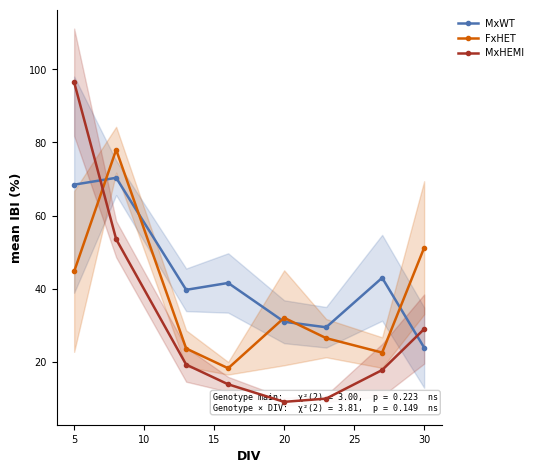


######################################################################
# Mean Burst Peak (norm.)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/

LMM: mean_Burst_Peak ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)            15.723    2     0.0004    ***
  Genotype × DIV (trajectory)        1.283    2     0.5264     ns

  ── Interpretation ───────────────────────────────────────────
  ✦ Persistent genotype shift (main p = 0.0004); slopes parallel.
    Active Area is offset between groups but tracks together over time.
    → Absolute threshold inappropriate; use per-genotype cutoffs.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                  1.692     0.0906     ns
  MxWT vs MxHEMI                 1.988     0.0468      *
  FxHET vs MxHEMI                0.632     0.5276     ns

  ── Fixed-effect coeff

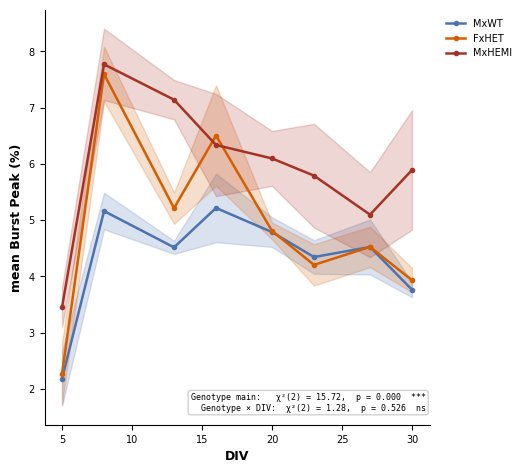


######################################################################
# Number of Bursts
######################################################################
LMM: Number_Bursts ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)            22.102    2     0.0000    ***
  Genotype × DIV (trajectory)        7.315    2     0.0258      *

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0258).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                  0.219     

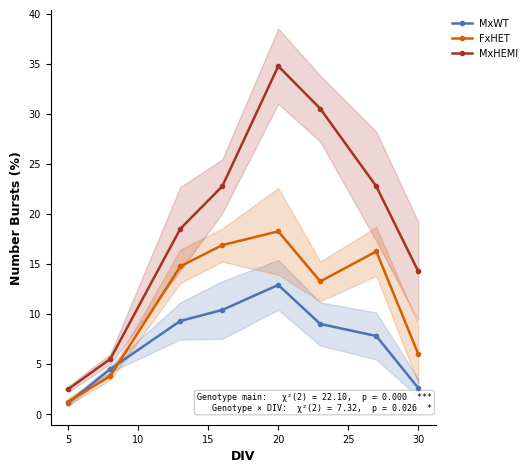


######################################################################
# Mean Spikes per Burst
######################################################################
LMM: mean_Spike_per_Burst ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             9.789    2     0.0075     **
  Genotype × DIV (trajectory)        2.025    2     0.3633     ns

  ── Interpretation ───────────────────────────────────────────
  ✦ Persistent genotype shift (main p = 0.0075); slopes parallel.
    Active Area is offset between groups but tracks together over time.
    → Absolute threshold inappropriate; use per-genotype cutoffs.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET        

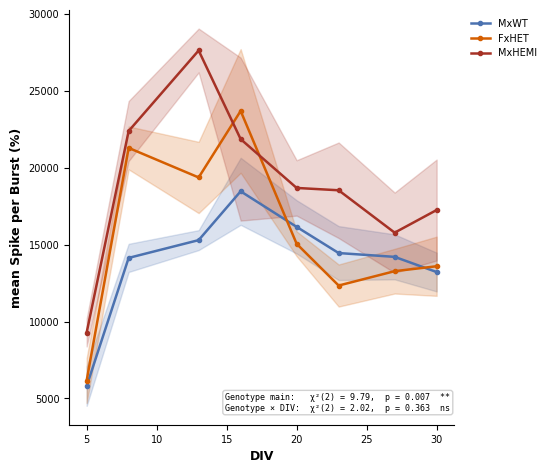


######################################################################
# Mean Burst Duration (s)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


LMM: mean_BurstDuration ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             0.402    2     0.8180     ns
  Genotype × DIV (trajectory)        6.382    2     0.0411      *

  ── Interpretation ───────────────────────────────────────────
  ✦ Trajectories DIVERGE over time (interaction p = 0.0411).
    Active Area differences are DIV-dependent.
    → Do NOT use an absolute threshold filter.
      Use within-genotype (MAD) QC only.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                  1.032     0.3022     ns
  MxWT vs MxHEMI                 1.704     0.0883     ns
  FxHET vs MxHEMI                0.856     0.3922     ns

  ── Fixed-effect coefficien

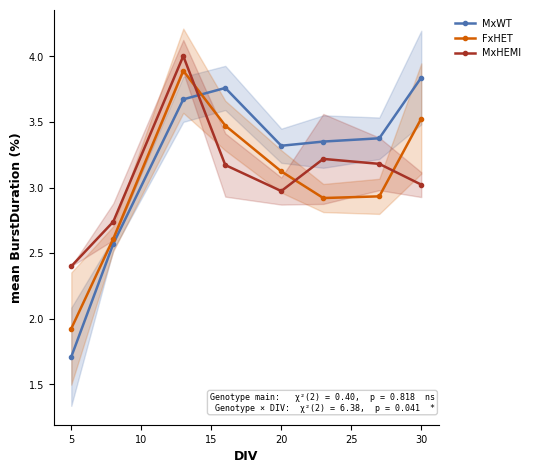


── LMM summary across metrics ──────────────────────────────────
              Metric  Main p Main sig  Interaction p Interaction sig
            mean_IBI  0.2228       ns         0.1488              ns
     mean_Burst_Peak  0.0004      ***         0.5264              ns
       Number_Bursts  0.0000      ***         0.0258               *
mean_Spike_per_Burst  0.0075       **         0.3633              ns
  mean_BurstDuration  0.8180       ns         0.0411               *


In [2]:
# LMM: value ~ Genotype * DIV + (1 | CHIP_WELL)
# Two LRTs per metric: main genotype effect + genotype × DIV interaction.

lmm_results = {}

for metric, ylabel in METRICS:
    if metric not in df.columns:
        continue
    print(f'\n{"#"*70}')
    print(f'# {ylabel}')
    print(f'{"#"*70}')
    fig, ax_data, ax_fit, lrt = test_genotype_lmm(
        df,
        group_col='NeuronType',
        div_col='DIV',
        value_col=metric,
        unit_col='CHIP_WELL',
        group_order=GROUP_ORDER,
        palette=PALETTE,
        figsize=(5.5, 5.0),
        save_path=os.path.join(DIRPATH, f'{metric}_lmm.svg'),
    )
    lmm_results[metric] = lrt
    plt.show()

# Summary table
rows = []
for metric, lrt in lmm_results.items():
    rows.append({
        'Metric':          metric,
        'Main p':          round(lrt['main']['p'], 4),
        'Main sig':        ('***' if lrt['main']['p'] < 0.001 else '**' if lrt['main']['p'] < 0.01
                            else '*' if lrt['main']['p'] < 0.05 else 'ns'),
        'Interaction p':   round(lrt['interaction']['p'], 4),
        'Interaction sig': ('***' if lrt['interaction']['p'] < 0.001 else '**' if lrt['interaction']['p'] < 0.01
                            else '*' if lrt['interaction']['p'] < 0.05 else 'ns'),
    })
print('\n── LMM summary across metrics ──────────────────────────────────')
print(pd.DataFrame(rows).to_string(index=False))


==================== STATS (KW + Wilcoxon, BH-FDR): mean_IBI ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=0.774 p=0.3791 → ns (no pairwise tests)
  DIV 16: KW H=9.051 p=0.01083 → pairwise tests
  DIV 23: KW H=7.515 p=0.02334 → pairwise tests

  BH-FDR: 3/6 pairs significant (q < 0.05)


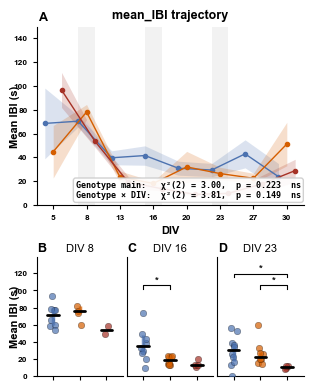

mean_IBI — significant pairs (q < 0.05):
 DIV      comparison    q_val Sig
  16   MxWT vs FxHET 0.038554   *
  23 FxHET vs MxHEMI 0.038554   *
  23  MxWT vs MxHEMI 0.047303   *


==================== STATS (KW + Wilcoxon, BH-FDR): mean_Burst_Peak ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=6.943 p=0.008415 → pairwise tests
  DIV 16: KW H=5.030 p=0.08086 → ns (no pairwise tests)
  DIV 23: KW H=4.639 p=0.09834 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


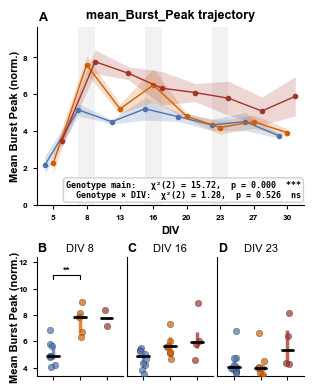

mean_Burst_Peak — significant pairs (q < 0.05):
 DIV    comparison    q_val Sig
   8 MxWT vs FxHET 0.008415  **


==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=1.708 p=0.1913 → ns (no pairwise tests)
  DIV 16: KW H=9.345 p=0.009347 → pairwise tests
  DIV 23: KW H=10.869 p=0.004364 → pairwise tests

  BH-FDR: 4/6 pairs significant (q < 0.05)


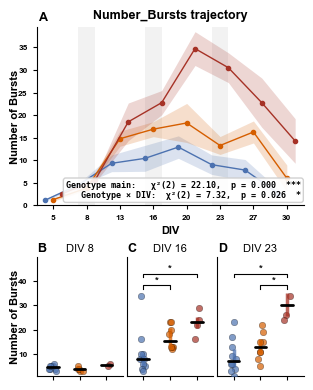

Number_Bursts — significant pairs (q < 0.05):
 DIV      comparison    q_val Sig
  16   MxWT vs FxHET 0.025702   *
  16  MxWT vs MxHEMI 0.042566   *
  23 FxHET vs MxHEMI 0.019735   *
  23  MxWT vs MxHEMI 0.019735   *


==================== STATS (KW + Wilcoxon, BH-FDR): mean_Spike_per_Burst ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=7.736 p=0.005414 → pairwise tests
  DIV 16: KW H=1.201 p=0.5486 → ns (no pairwise tests)
  DIV 23: KW H=5.259 p=0.0721 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


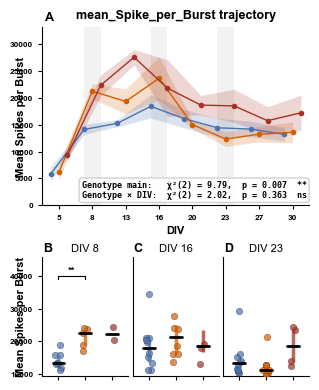

mean_Spike_per_Burst — significant pairs (q < 0.05):
 DIV    comparison    q_val Sig
   8 MxWT vs FxHET 0.005414  **


==================== STATS (KW + Wilcoxon, BH-FDR): mean_BurstDuration ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=0.022 p=0.8833 → ns (no pairwise tests)
  DIV 16: KW H=4.281 p=0.1176 → ns (no pairwise tests)
  DIV 23: KW H=3.334 p=0.1888 → ns (no pairwise tests)


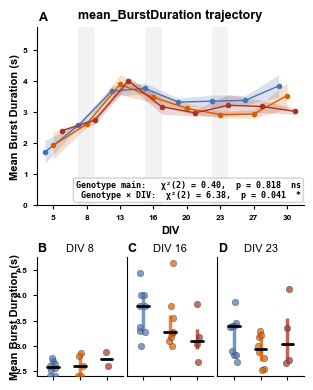

mean_BurstDuration — no significant pairs after FDR correction



In [3]:
# KW omnibus → pairwise Wilcoxon → BH-FDR across all (selected_div × pair)
# tests within each metric.  Stars shown only where q < 0.05.

viz = meaplotter.MEAPlotter(group_order=GROUP_ORDER, palette=PALETTE)
os.makedirs(DIRPATH, exist_ok=True)

for metric, ylabel in METRICS:
    stats = viz.calculate_stats_at_timepoints(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
    )

    fig, ax_traj, ax_dots = viz.plot_trajectory_with_dotplots(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, stats_df=stats,
        lmm_results=lmm_results.get(metric),
        group_order=GROUP_ORDER, palette=PALETTE, ylabel=ylabel,
        figsize=(3.0, 4.2), height_ratios=(3, 2),
    )
    fig.savefig(os.path.join(DIRPATH, f'{metric}_FDR.svg'), format='svg', bbox_inches='tight')
    plt.show()

    sig = stats[stats['reject'] == True][['DIV', 'comparison', 'q_val', 'Sig']]
    if not sig.empty:
        print(f'{metric} — significant pairs (q < 0.05):')
        print(sig.to_string(index=False))
    else:
        print(f'{metric} — no significant pairs after FDR correction')
    print()

In [5]:
# ── Export all stats to text + Excel ──────────────────────────────────────
# Requires: lmm_results and viz from cells above to have been run.
import io, contextlib

txt_path  = os.path.join(DIRPATH, 'stats_report.txt')
xlsx_path = os.path.join(DIRPATH, 'stats_report.xlsx')

fdr_frames   = {}   # metric -> full stats DataFrame
lmm_summary  = []   # one row per metric for the LMM omnibus summary
wald_frames  = {}   # metric -> pairwise Wald DataFrame

with open(txt_path, 'w') as fout:
    fout.write(f"Statistical Report — Network Metrics\n")
    fout.write(f"Groups: {GROUP_ORDER}  |  Selected DIVs: {SELECTED_DIVS}\n")
    fout.write("=" * 70 + "\n\n")

    for metric, ylabel in METRICS:
        fout.write(f"\n{'#' * 70}\n# {ylabel}  [{metric}]\n{'#' * 70}\n\n")

        # ── LMM ──────────────────────────────────────────────────────────
        fout.write("── LMM ──\n")
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            _, _, _, lrt = test_genotype_lmm(
                df, group_col='NeuronType', div_col='DIV', value_col=metric,
                unit_col='CHIP_WELL', group_order=GROUP_ORDER, palette=PALETTE,
                plot=False,
            )
        fout.write(buf.getvalue())
        fout.write("\n")

        lmm_summary.append({
            'Metric':          metric,
            'ylabel':          ylabel,
            'Main χ²':         round(lrt['main']['chi2'], 3),
            'Main df':         lrt['main']['df'],
            'Main p':          round(lrt['main']['p'], 4),
            'Interaction χ²':  round(lrt['interaction']['chi2'], 3),
            'Interaction df':  lrt['interaction']['df'],
            'Interaction p':   round(lrt['interaction']['p'], 4),
        })

        # Wald pairwise from lmm_results (already computed in cell-1)
        if metric in lmm_results and 'pairwise_wald' in lmm_results[metric]:
            wald_rows = [
                {'comparison': f"{g1} vs {g2}", 'z': round(v['z'], 3), 'p': round(v['p'], 4)}
                for (g1, g2), v in lmm_results[metric]['pairwise_wald'].items()
            ]
            wald_frames[metric] = pd.DataFrame(wald_rows)
            fout.write("── LMM pairwise Wald ──\n")
            fout.write(wald_frames[metric].to_string(index=False) + "\n\n")

        # ── KW / Wilcoxon / BH-FDR ───────────────────────────────────────
        fout.write("── KW → Wilcoxon → BH-FDR ──\n")
        buf2 = io.StringIO()
        with contextlib.redirect_stdout(buf2):
            stats = viz.calculate_stats_at_timepoints(
                df, div_col='DIV', group_col='NeuronType', y=metric,
                selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
            )
        fout.write(buf2.getvalue())
        stats['metric'] = metric
        fdr_frames[metric] = stats
        fout.write(stats[['DIV', 'comparison', 'KW_stat', 'KW_p',
                           'W_stat', 'raw_p', 'q_val', 'Sig',
                           'Grp1_Stats', 'Grp2_Stats', "Cohen's d"]
                         ].to_string(index=False))
        fout.write("\n")

print(f"Text report → {txt_path}")

# ── Excel: one sheet per metric (FDR) + LMM summary sheet ────────────────
with pd.ExcelWriter(xlsx_path, engine='openpyxl') as writer:
    pd.DataFrame(lmm_summary).to_excel(writer, sheet_name='LMM_summary', index=False)
    for metric, df_s in fdr_frames.items():
        sheet = metric[:31]   # Excel sheet name limit
        df_s.to_excel(writer, sheet_name=sheet, index=False)
    for metric, df_w in wald_frames.items():
        sheet = (metric[:27] + '_wald')[:31]
        df_w.to_excel(writer, sheet_name=sheet, index=False)

print(f"Excel report → {xlsx_path}")

Text report → /Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_Canonical/plots/stats_report.txt
Excel report → /Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_Canonical/plots/stats_report.xlsx


## HYPERBURST

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import importlib
import meaplotter
importlib.reload(meaplotter)

from activity_qc_plotter import test_genotype_lmm

# ── Config ────────────────────────────────────────────────────────────────
FILE_CSV      = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_hyperbursts/Compiled_Networks.csv'
DIRPATH       = '/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_hyperbursts/plots'
GROUP_ORDER   = ['MxWT', 'FxHET', 'MxHEMI']
PALETTE       = {'MxWT': '#4C72B0', 'FxHET': '#D55E00', 'MxHEMI': '#A63226'}
SELECTED_DIVS = [8, 16, 23]

METRICS = [
    ('mean_IBI',             'Mean IBI (s)'),
    ('mean_Burst_Peak',      'Mean Burst Peak (norm.)'),
    ('Number_Bursts',        'Number of Bursts'),
    ('mean_Spike_per_Burst', 'Mean Spikes per Burst'),
    ('mean_BurstDuration',   'Mean Burst Duration (s)'),
]

# ── Load + clean ──────────────────────────────────────────────────────────
df = pd.read_csv(FILE_CSV)
df['NeuronType'] = df['NeuronType'].str.strip()
df['Chip_ID']    = df['Chip_ID'].astype(str)
df['Well']       = df['Well'].astype(str)
df['CHIP_WELL']  = df['Chip_ID'] + '_' + df['Well']
df = df.replace(np.nan, 0.0)

# ── Exclude known bad wells ───────────────────────────────────────────────
EXCLUDE = {
('M07039','5'),('M07420','6')
}
mask = df.apply(lambda r: (r['Chip_ID'], r['Well']) in EXCLUDE, axis=1)
df = df[~mask].copy()

# ── Exclude specific (well, DIV) timepoints ───────────────────────────────
EXCLUDE_DIVS = {
    ('M07420', '5', 8),   # single MAD outlier, keep rest of well
}
mask_divs = df.apply(lambda r: (r['Chip_ID'], r['Well'], int(r['DIV'])) in EXCLUDE_DIVS, axis=1)
df = df[~mask_divs].copy()

print(f'Loaded {len(df)} rows | {df["CHIP_WELL"].nunique()} wells | '
      f'DIV {df["DIV"].min()}-{df["DIV"].max()}')
print('Groups:', df['NeuronType'].value_counts().to_dict())

Loaded 169 rows | 22 wells | DIV 5-30
Groups: {'MxWT': 78, 'FxHET': 61, 'MxHEMI': 30}


## Burst Duration Filtered Analysis (>2s threshold)

Rows with >=1 burst >2.0s: 164 / 169
CHIP_WELL  DIV NeuronType  mean_BurstDuration_2s  Number_Bursts_2s  mean_Burst_Peak_2s  mean_SpikesPerBurst_2s  mean_IBI_2s
 M07039_1    5     MxHEMI                    2.4                 2             3.89225                 10398.0         64.8
 M07039_2    5       MxWT                    NaN                 0                 NaN                     NaN          NaN
 M07039_3    5      FxHET                    NaN                 0                 NaN                     NaN          NaN
 M07039_4    5     MxHEMI                    2.4                 2             3.11375                  8468.5        118.8
 M07039_6    5      FxHET                    NaN                 0                 NaN                     NaN          NaN
 M07420_1    5       MxWT                    2.4                 1             3.73150                  9737.0          NaN
 M07420_2    5       MxWT                    2.4                 2             3.02755         

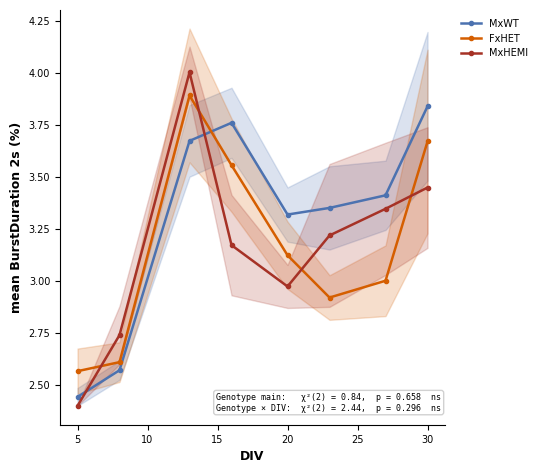


######################################################################
# Number of Bursts >2s
######################################################################
LMM: Number_Bursts_2s ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)            21.250    2     0.0000    ***
  Genotype × DIV (trajectory)        5.867    2     0.0532     ns

  ── Interpretation ───────────────────────────────────────────
  ✦ Persistent genotype shift (main p = 0.0000); slopes parallel.
    Active Area is offset between groups but tracks together over time.
    → Absolute threshold inappropriate; use per-genotype cutoffs.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET             

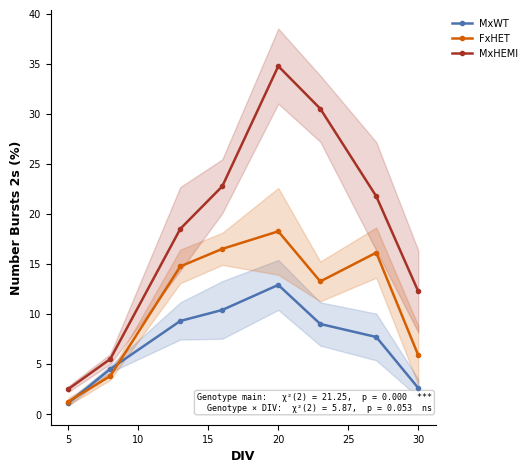


######################################################################
# Mean Burst Peak >2s (norm.)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/

LMM: mean_Burst_Peak_2s ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)            17.109    2     0.0002    ***
  Genotype × DIV (trajectory)        3.009    2     0.2221     ns

  ── Interpretation ───────────────────────────────────────────
  ✦ Persistent genotype shift (main p = 0.0002); slopes parallel.
    Active Area is offset between groups but tracks together over time.
    → Absolute threshold inappropriate; use per-genotype cutoffs.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                  1.854     0.0637     ns
  MxWT vs MxHEMI                 1.167     0.2433     ns
  FxHET vs MxHEMI               -0.344     0.7311     ns

  ── Fixed-effect co

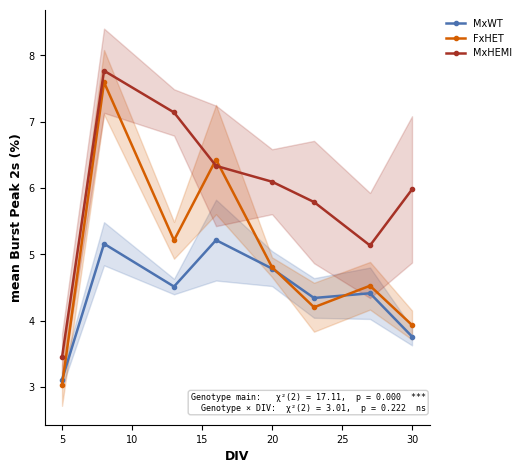


######################################################################
# Mean Spikes per Burst >2s
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


LMM: mean_SpikesPerBurst_2s ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             9.402    2     0.0091     **
  Genotype × DIV (trajectory)        2.190    2     0.3346     ns

  ── Interpretation ───────────────────────────────────────────
  ✦ Persistent genotype shift (main p = 0.0091); slopes parallel.
    Active Area is offset between groups but tracks together over time.
    → Absolute threshold inappropriate; use per-genotype cutoffs.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                  1.750     0.0802     ns
  MxWT vs MxHEMI                 1.176     0.2398     ns
  FxHET vs MxHEMI               -0.253     0.8003     ns

  ── Fixed-effec

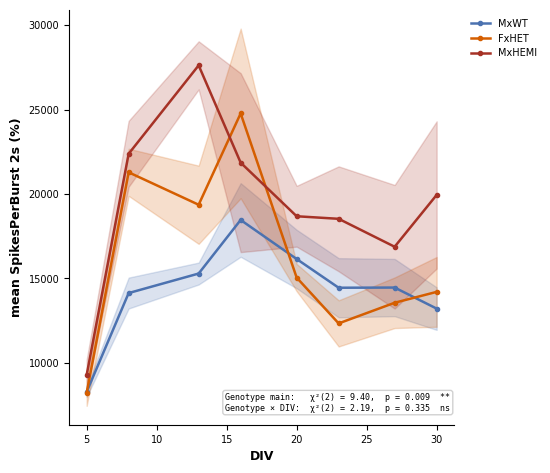


######################################################################
# Mean IBI between >2s Bursts (s)
######################################################################


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


LMM: mean_IBI_2s ~ NeuronType * DIV + (1 | CHIP_WELL)
Reference: MxWT   |   n wells: 22

  Effect                                χ²   df          p       
  -------------------------------- -------  ---  ---------  -----
  Genotype (main effect)             8.232    2     0.0163      *
  Genotype × DIV (trajectory)        2.301    2     0.3165     ns

  ── Interpretation ───────────────────────────────────────────
  ✦ Persistent genotype shift (main p = 0.0163); slopes parallel.
    Active Area is offset between groups but tracks together over time.
    → Absolute threshold inappropriate; use per-genotype cutoffs.

  ── Pairwise Wald tests (full model) ─────────────────────────
  Comparison                         z          p       
  ---------------------------- -------  ---------  -----
  MxWT vs FxHET                 -1.883     0.0597     ns
  MxWT vs MxHEMI                -1.185     0.2360     ns
  FxHET vs MxHEMI                0.485     0.6276     ns

  ── Fixed-effect coefficie

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


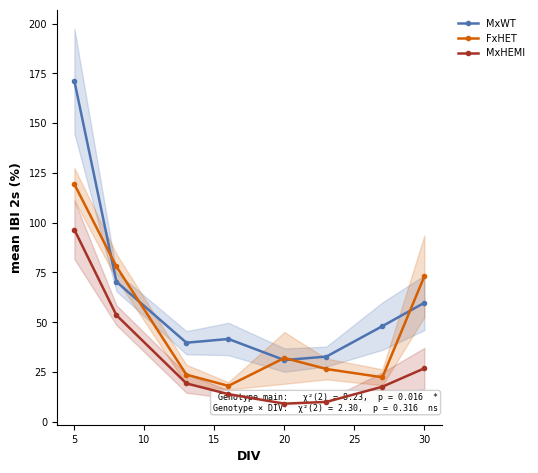


── LMM summary ──────────────────────────────────────────────────
                Metric  Main p Main sig  Interaction p Interaction sig
 mean_BurstDuration_2s  0.6575       ns         0.2957              ns
      Number_Bursts_2s  0.0000      ***         0.0532              ns
    mean_Burst_Peak_2s  0.0002      ***         0.2221              ns
mean_SpikesPerBurst_2s  0.0091       **         0.3346              ns
           mean_IBI_2s  0.0163        *         0.3165              ns

==================== STATS (KW + Wilcoxon, BH-FDR): mean_BurstDuration_2s ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=0.138 p=0.7102 → ns (no pairwise tests)
  DIV 16: KW H=3.658 p=0.1606 → ns (no pairwise tests)
  DIV 23: KW H=3.336 p=0.1886 → ns (no pairwise tests)


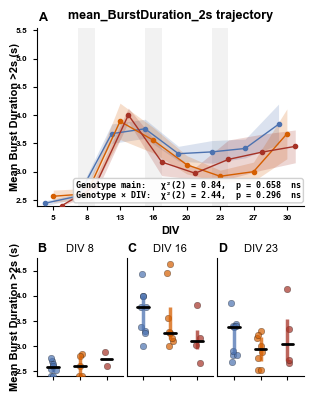

mean_BurstDuration_2s — no significant pairs after FDR correction


==================== STATS (KW + Wilcoxon, BH-FDR): Number_Bursts_2s ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=1.708 p=0.1913 → ns (no pairwise tests)
  DIV 16: KW H=9.345 p=0.009347 → pairwise tests
  DIV 23: KW H=10.869 p=0.004364 → pairwise tests

  BH-FDR: 4/6 pairs significant (q < 0.05)


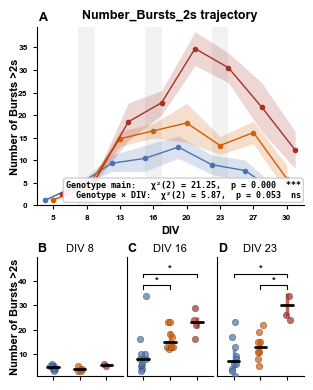

Number_Bursts_2s — significant pairs (q < 0.05):
 DIV      comparison    q_val Sig
  16   MxWT vs FxHET 0.025702   *
  16  MxWT vs MxHEMI 0.042566   *
  23 FxHET vs MxHEMI 0.019735   *
  23  MxWT vs MxHEMI 0.019735   *


==================== STATS (KW + Wilcoxon, BH-FDR): mean_Burst_Peak_2s ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=6.943 p=0.008415 → pairwise tests
  DIV 16: KW H=5.030 p=0.08086 → ns (no pairwise tests)
  DIV 23: KW H=4.639 p=0.09834 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


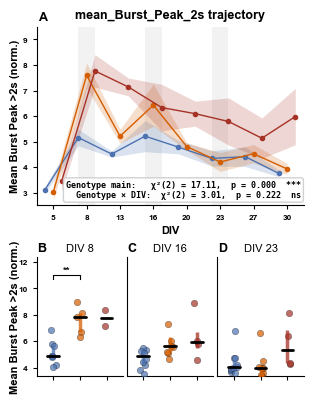

mean_Burst_Peak_2s — significant pairs (q < 0.05):
 DIV    comparison    q_val Sig
   8 MxWT vs FxHET 0.008415  **


==================== STATS (KW + Wilcoxon, BH-FDR): mean_SpikesPerBurst_2s ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=7.736 p=0.005414 → pairwise tests
  DIV 16: KW H=1.201 p=0.5486 → ns (no pairwise tests)
  DIV 23: KW H=5.259 p=0.0721 → ns (no pairwise tests)

  BH-FDR: 1/1 pairs significant (q < 0.05)


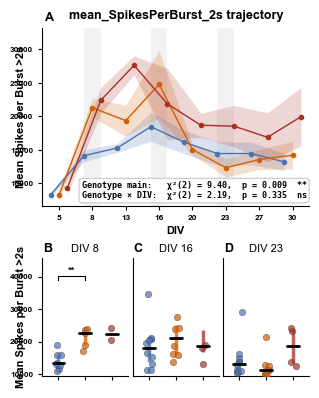

mean_SpikesPerBurst_2s — significant pairs (q < 0.05):
 DIV    comparison    q_val Sig
   8 MxWT vs FxHET 0.005414  **


==================== STATS (KW + Wilcoxon, BH-FDR): mean_IBI_2s ====================
Selected timepoints: [8, 16, 23]  min_n=3
  DIV 8: KW H=0.774 p=0.3791 → ns (no pairwise tests)
  DIV 16: KW H=8.707 p=0.01286 → pairwise tests
  DIV 23: KW H=9.886 p=0.007133 → pairwise tests

  BH-FDR: 3/6 pairs significant (q < 0.05)


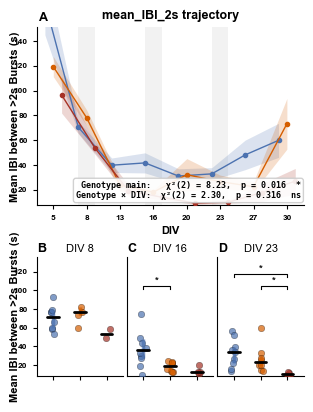

mean_IBI_2s — significant pairs (q < 0.05):
 DIV      comparison    q_val Sig
  16   MxWT vs FxHET 0.025702   *
  23 FxHET vs MxHEMI 0.019735   *
  23  MxWT vs MxHEMI 0.019735   *



/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/

Text report → /Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_hyperbursts/plots/filtered_2s/stats_report_filtered_2s.txt
Excel report → /Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig3/Network_outputs_hyperbursts/plots/filtered_2s/stats_report_filtered_2s.xlsx


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [2]:
# ── Filtered Burst Analysis (>2s threshold) ───────────────────────────────
BURST_THRESH = 2.0
DIRPATH_FILT = os.path.join(DIRPATH, 'filtered_2s')
os.makedirs(DIRPATH_FILT, exist_ok=True)

METRICS_FILT = [
    ('mean_BurstDuration_2s',  'Mean Burst Duration >2s (s)'),
    ('Number_Bursts_2s',       'Number of Bursts >2s'),
    ('mean_Burst_Peak_2s',     'Mean Burst Peak >2s (norm.)'),
    ('mean_SpikesPerBurst_2s', 'Mean Spikes per Burst >2s'),
    ('mean_IBI_2s',            'Mean IBI between >2s Bursts (s)'),
]

def _parse_dist(x):
    if pd.isna(x) or x == 0.0 or str(x).strip() in ('', '0.0'):
        return []
    return [float(v) for v in str(x).split(',') if v.strip()]

def _filtered_mean(vals, mask):
    kept = [v for v, keep in zip(vals, mask) if keep]
    return np.mean(kept) if kept else np.nan

def _filtered_count(mask):
    return sum(mask)

def _ibi_filtered_mean(ibi_vals, burst_mask):
    # IBI[i] kept if burst[i] and burst[i+1] both pass threshold
    if len(ibi_vals) == 0 or len(burst_mask) < 2:
        return np.nan
    kept = [ibi for i, ibi in enumerate(ibi_vals)
            if i < len(burst_mask) - 1 and burst_mask[i] and burst_mask[i + 1]]
    return np.mean(kept) if kept else np.nan

burst_dur   = df['Burst_Duration_Distribution'].apply(_parse_dist)
burst_peak  = df['Burst_Peak_Distribution'].apply(_parse_dist)
spikes_pb   = df['SpikesPerBurst_Distribution'].apply(_parse_dist)
ibi         = df['IBI_Distribution'].apply(_parse_dist)

masks = burst_dur.apply(lambda v: [x > BURST_THRESH for x in v])

df['mean_BurstDuration_2s']  = [_filtered_mean(d, m) for d, m in zip(burst_dur, masks)]
df['Number_Bursts_2s']       = [_filtered_count(m) for m in masks]
df['mean_Burst_Peak_2s']     = [_filtered_mean(p, m) for p, m in zip(burst_peak, masks)]
df['mean_SpikesPerBurst_2s'] = [_filtered_mean(s, m) for s, m in zip(spikes_pb, masks)]
df['mean_IBI_2s']            = [_ibi_filtered_mean(i, m) for i, m in zip(ibi, masks)]

print(f'Rows with >=1 burst >{BURST_THRESH}s: {df["mean_BurstDuration_2s"].notna().sum()} / {len(df)}')
print(df[['CHIP_WELL', 'DIV', 'NeuronType'] + [m for m, _ in METRICS_FILT]].head(10).to_string(index=False))

# ── LMM ──────────────────────────────────────────────────────────────────
lmm_results_filt = {}
for metric, ylabel in METRICS_FILT:
    print(f'\n{"#"*70}\n# {ylabel}\n{"#"*70}')
    fig, ax_data, ax_fit, lrt = test_genotype_lmm(
        df,
        group_col='NeuronType', div_col='DIV', value_col=metric,
        unit_col='CHIP_WELL', group_order=GROUP_ORDER, palette=PALETTE,
        figsize=(5.5, 5.0),
        save_path=os.path.join(DIRPATH_FILT, f'{metric}_lmm.svg'),
    )
    lmm_results_filt[metric] = lrt
    plt.show()

rows = []
for metric, lrt in lmm_results_filt.items():
    rows.append({
        'Metric':          metric,
        'Main p':          round(lrt['main']['p'], 4),
        'Main sig':        ('***' if lrt['main']['p'] < 0.001 else '**' if lrt['main']['p'] < 0.01
                            else '*' if lrt['main']['p'] < 0.05 else 'ns'),
        'Interaction p':   round(lrt['interaction']['p'], 4),
        'Interaction sig': ('***' if lrt['interaction']['p'] < 0.001 else '**' if lrt['interaction']['p'] < 0.01
                            else '*' if lrt['interaction']['p'] < 0.05 else 'ns'),
    })
print('\n── LMM summary ──────────────────────────────────────────────────')
print(pd.DataFrame(rows).to_string(index=False))

# ── KW → Wilcoxon → BH-FDR ───────────────────────────────────────────────
viz_filt = meaplotter.MEAPlotter(group_order=GROUP_ORDER, palette=PALETTE)

for metric, ylabel in METRICS_FILT:
    stats = viz_filt.calculate_stats_at_timepoints(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
    )
    fig, ax_traj, ax_dots = viz_filt.plot_trajectory_with_dotplots(
        df, div_col='DIV', group_col='NeuronType', y=metric,
        selected_divs=SELECTED_DIVS, stats_df=stats,
        lmm_results=lmm_results_filt.get(metric),
        group_order=GROUP_ORDER, palette=PALETTE, ylabel=ylabel,
        figsize=(3.0, 4.2), height_ratios=(3, 2),
    )
    fig.savefig(os.path.join(DIRPATH_FILT, f'{metric}_FDR.svg'), format='svg', bbox_inches='tight')
    plt.show()

    sig = stats[stats['reject'] == True][['DIV', 'comparison', 'q_val', 'Sig']]
    if not sig.empty:
        print(f'{metric} — significant pairs (q < 0.05):')
        print(sig.to_string(index=False))
    else:
        print(f'{metric} — no significant pairs after FDR correction')
    print()

# ── Export ────────────────────────────────────────────────────────────────
import io, contextlib

txt_path_filt  = os.path.join(DIRPATH_FILT, 'stats_report_filtered_2s.txt')
xlsx_path_filt = os.path.join(DIRPATH_FILT, 'stats_report_filtered_2s.xlsx')

fdr_frames_filt  = {}
lmm_summary_filt = []

with open(txt_path_filt, 'w') as fout:
    fout.write(f'Statistical Report — Burst Analysis Filtered (>{BURST_THRESH}s)\n')
    fout.write(f'Groups: {GROUP_ORDER}  |  Selected DIVs: {SELECTED_DIVS}\n')
    fout.write('=' * 70 + '\n\n')

    for metric, ylabel in METRICS_FILT:
        fout.write(f"\n{'#'*70}\n# {ylabel}  [{metric}]\n{'#'*70}\n\n")
        fout.write('── LMM ──\n')
        buf = io.StringIO()
        with contextlib.redirect_stdout(buf):
            _, _, _, lrt = test_genotype_lmm(
                df, group_col='NeuronType', div_col='DIV', value_col=metric,
                unit_col='CHIP_WELL', group_order=GROUP_ORDER, palette=PALETTE, plot=False,
            )
        fout.write(buf.getvalue() + '\n')

        lmm_summary_filt.append({
            'Metric':           metric,
            'ylabel':           ylabel,
            'Main chi2':        round(lrt['main']['chi2'], 3),
            'Main df':          lrt['main']['df'],
            'Main p':           round(lrt['main']['p'], 4),
            'Interaction chi2': round(lrt['interaction']['chi2'], 3),
            'Interaction df':   lrt['interaction']['df'],
            'Interaction p':    round(lrt['interaction']['p'], 4),
        })

        fout.write('── KW → Wilcoxon → BH-FDR ──\n')
        buf2 = io.StringIO()
        with contextlib.redirect_stdout(buf2):
            stats = viz_filt.calculate_stats_at_timepoints(
                df, div_col='DIV', group_col='NeuronType', y=metric,
                selected_divs=SELECTED_DIVS, group_order=GROUP_ORDER,
            )
        fout.write(buf2.getvalue())
        stats['metric'] = metric
        fdr_frames_filt[metric] = stats
        fout.write(stats[['DIV', 'comparison', 'KW_stat', 'KW_p',
                           'W_stat', 'raw_p', 'q_val', 'Sig',
                           'Grp1_Stats', 'Grp2_Stats', "Cohen's d"]
                         ].to_string(index=False) + '\n')

print(f'Text report → {txt_path_filt}')

with pd.ExcelWriter(xlsx_path_filt, engine='openpyxl') as writer:
    pd.DataFrame(lmm_summary_filt).to_excel(writer, sheet_name='LMM_summary', index=False)
    for metric, df_s in fdr_frames_filt.items():
        df_s.to_excel(writer, sheet_name=metric[:31], index=False)

print(f'Excel report → {xlsx_path_filt}')
